## Risky Business - Sussy business

This model takes historical stock data, and predicts which stocks are looking scrumptiously good right now.

How it would work:
1. Collect stock market data [https://pypi.org/project/yfinance/]
2. Extract patterns
3. See the relations with ML!
4. Predict future stocks
5. Build a simulated portfolio
6. Measures if the strategy would work

In [ ]:
!pip install yfinance

In [5]:
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report

In [8]:
stocks = ["AAPL", "MSFT", "NVDA", "AMZN", "META", "GOOGL", "JPM", "XOM", "LLY", "COST"]
benchmark = "SPY"

start_date = "2018-01-01"
end_date = "2025-01-01"

In [9]:
def download_data(stocks, start, end):
    data = yf.download(stocks, start=start, end=end, auto_adjust=True)
    return data

raw_data = download_data(stocks + [benchmark], start_date, end_date)
print(raw_data.head())

/Users/sam/anaconda3/lib/python3.11/site-packages/yfinance/scrapers/history.py:389: FutureWarning: The default dtype for empty Series will be 'object' instead of 'float64' in a future version. Specify a dtype explicitly to silence this warning.
  self._capital_gains = pd.Series()
/Users/sam/anaconda3/lib/python3.11/site-packages/yfinance/scrapers/history.py:389: FutureWarning: The default dtype for empty Series will be 'object' instead of 'float64' in a future version. Specify a dtype explicitly to silence this warning.
  self._capital_gains = pd.Series()
/Users/sam/anaconda3/lib/python3.11/site-packages/yfinance/scrapers/history.py:389: FutureWarning: The default dtype for empty Series will be 'object' instead of 'float64' in a future version. Specify a dtype explicitly to silence this warning.
  self._capital_gains = pd.Series()
/Users/sam/anaconda3/lib/python3.11/site-packages/yfinance/scrapers/history.py:389: FutureWarning: The default dtype for empty Series will be 'object' instea

Price           Close                                                          \
Ticker           AAPL       AMZN        COST      GOOGL        JPM        LLY   
Date                                                                            
2018-01-02  40.267082  59.450500  168.254059  53.220631  85.901253  74.897781   
2018-01-03  40.260063  60.209999  170.273163  54.128628  85.988792  75.304619   
2018-01-04  40.447079  60.479500  168.950882  54.338890  87.220642  75.640739   
2018-01-05  40.907574  61.457001  167.744843  55.059433  86.660713  76.569443   
2018-01-08  40.755638  62.343498  168.396957  55.253826  86.788696  76.180267   

Price                                                    ...    Volume  \
Ticker            META       MSFT      NVDA         SPY  ...      AMZN   
Date                                                     ...             
2018-01-02  180.007401  78.870346  4.928267  236.562180  ...  53890000   
2018-01-03  183.232086  79.237419  5.252614  238.058411

In [10]:
def create_features(data, ticker):
    df = pd.DataFrame()
    df["close"] = data["Close"][ticker]
    df["volume"] = data["Volume"][ticker]

    df["daily_return"] = df["close"].pct_change()
    df["return_5d"] = df["close"].pct_change(5)
    df["return_20d"] = df["close"].pct_change(20)

    df["volatility_20d"] = df["daily_return"].rolling(20).std()
    df["moving_avg_20d"] = df["close"].rolling(20).mean()
    df["moving_avg_ratio"] = df["close"] / df["moving_avg_20d"]

    df["volume_ratio"] = df["volume"] / df["volume"].rolling(20).mean()

    df["ticker"] = ticker
    return df

In [11]:
def add_target(df, spy_returns):
    df["future_return_5d"] = df["close"].pct_change(5).shift(-5)
    df["spy_future_return_5d"] = spy_returns.shift(-5)
    df["target"] = (df["future_return_5d"] > df["spy_future_return_5d"]).astype(int)
    return df

In [12]:
spy_close = raw_data["Close"][benchmark]
spy_returns_5d = spy_close.pct_change(5)

all_data = []

for ticker in tickers:
    features = create_features(raw_data, ticker)
    features = add_target(features, spy_returns_5d)
    all_data.append(features)

dataset = pd.concat(all_data)
dataset = dataset.dropna()

print(dataset.head())

                close     volume  daily_return  return_5d  return_20d  \
Date                                                                    
2018-01-31  39.138027  129915600      0.002755  -0.038974   -0.028039   
2018-02-01  39.219845  188923200      0.002090  -0.019461   -0.025837   
2018-02-02  37.518089  346375200     -0.043390  -0.064194   -0.072415   
2018-02-05  36.580711  290954000     -0.024985  -0.068290   -0.105772   
2018-02-06  38.109505  272975200      0.041792  -0.023597   -0.064927   

            volatility_20d  moving_avg_20d  moving_avg_ratio  volume_ratio  \
Date                                                                         
2018-01-31        0.009462       40.695439          0.961730      1.024371   
2018-02-01        0.009490       40.643428          0.964974      1.449161   
2018-02-02        0.013250       40.496978          0.926442      2.418836   
2018-02-05        0.013567       40.280635          0.908146      1.901476   
2018-02-06        0.

In [13]:
features = [
    "return_5d",
    "return_20d",
    "volatility_20d",
    "moving_avg_ratio",
    "volume_ratio"
]

X = dataset[features]
y = dataset["target"]

split_date = "2023-01-01"

train = dataset[dataset.index < split_date]
test = dataset[dataset.index >= split_date]

X_train = train[features]
y_train = train["target"]

X_test = test[features]
y_test = test["target"]

model = RandomForestClassifier(
    n_estimators=200,
    max_depth=5,
    random_state=42
)

model.fit(X_train, y_train)

predictions = model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, predictions))
print(classification_report(y_test, predictions))

Accuracy: 0.5346076458752516
              precision    recall  f1-score   support

           0       0.44      0.12      0.19      2244
           1       0.55      0.87      0.67      2726

    accuracy                           0.53      4970
   macro avg       0.50      0.50      0.43      4970
weighted avg       0.50      0.53      0.46      4970



In [14]:
test = test.copy()
test["predicted_score"] = model.predict_proba(X_test)[:, 1]

print(test[["ticker", "predicted_score", "future_return_5d"]].head())

           ticker  predicted_score  future_return_5d
Date                                                
2023-01-03   AAPL         0.555428          0.045255
2023-01-04   AAPL         0.516932          0.056426
2023-01-05   AAPL         0.505808          0.067109
2023-01-06   AAPL         0.502724          0.039654
2023-01-09   AAPL         0.498607          0.044487


In [15]:
def backtest_strategy(test_data, top_n=3):
    portfolio_returns = []

    for date, group in test_data.groupby(test_data.index):
        top_stocks = group.sort_values("predicted_score", ascending=False).head(top_n)
        daily_return = top_stocks["future_return_5d"].mean()

        portfolio_returns.append({
            "date": date,
            "strategy_return": daily_return
        })

    results = pd.DataFrame(portfolio_returns)
    results = results.dropna()
    results = results.set_index("date")

    return results

backtest = backtest_strategy(test, top_n=3)
print(backtest.head())

            strategy_return
date                       
2023-01-03         0.041024
2023-01-04         0.028255
2023-01-05         0.034672
2023-01-06         0.032231
2023-01-09         0.029566


In [16]:
spy_test = spy_returns_5d[spy_returns_5d.index >= split_date]
backtest["spy_return"] = spy_test
backtest = backtest.dropna()

backtest["strategy_cumulative"] = (1 + backtest["strategy_return"]).cumprod()
backtest["spy_cumulative"] = (1 + backtest["spy_return"]).cumprod()

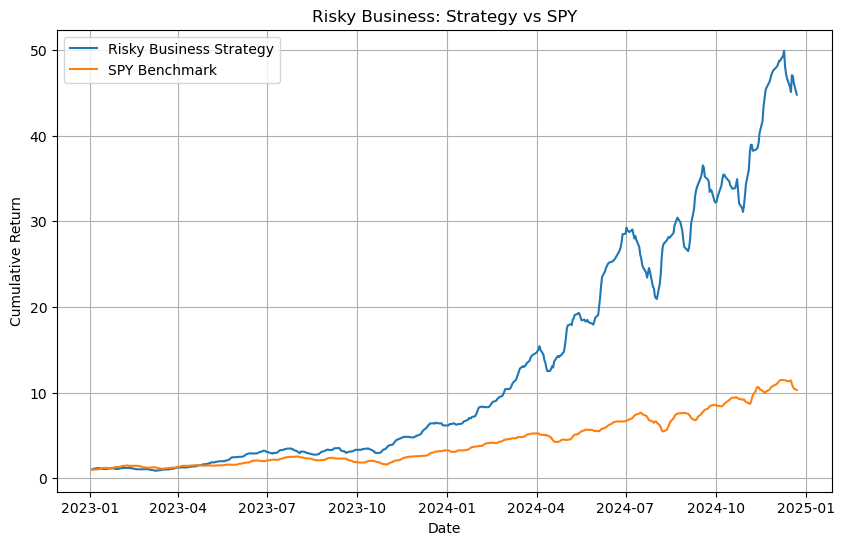

In [17]:
##PLOT
plt.figure(figsize=(10, 6))
plt.plot(backtest.index, backtest["strategy_cumulative"], label="Risky Business Strategy")
plt.plot(backtest.index, backtest["spy_cumulative"], label="SPY Benchmark")
plt.title("Risky Business: Strategy vs SPY")
plt.xlabel("Date")
plt.ylabel("Cumulative Return")
plt.legend()
plt.grid(True)
plt.show()

In [18]:
def sharpe_ratio(returns):
    return returns.mean() / returns.std() * np.sqrt(252 / 5)

def max_drawdown(cumulative_returns):
    running_max = cumulative_returns.cummax()
    drawdown = cumulative_returns / running_max - 1
    return drawdown.min()

strategy_sharpe = sharpe_ratio(backtest["strategy_return"])
spy_sharpe = sharpe_ratio(backtest["spy_return"])

strategy_drawdown = max_drawdown(backtest["strategy_cumulative"])
spy_drawdown = max_drawdown(backtest["spy_cumulative"])

print("Strategy Sharpe:", strategy_sharpe)
print("SPY Sharpe:", spy_sharpe)
print("Strategy Max Drawdown:", strategy_drawdown)
print("SPY Max Drawdown:", spy_drawdown)

Strategy Sharpe: 2.4815351654039444
SPY Sharpe: 1.9371311109246725
Strategy Max Drawdown: -0.2846745890137278
SPY Max Drawdown: -0.364158657370092
